In [1]:
import librosa
import numpy as np
import os
from skimage.feature import local_binary_pattern


def extract_mfcc(y, sr, n_mfcc=13, n_fft=512, hop_length=160, win_length=400, n_mels=40):
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        win_length=win_length
    )

    if mfcc.shape[1] < 9: return None

    delta = librosa.feature.delta(mfcc)

    # delta-delta
    delta2 = librosa.feature.delta(mfcc, order=2)

    # ghép feature
    feat_all = np.vstack([mfcc, delta, delta2]).T
    # CMVN
    return feat_all   # (num_frames, n_mfcc)


In [ ]:
import numpy as np
import librosa
from skimage.feature import local_binary_pattern

def build_mfcc_dataset(
    wav_list,
    sr=16000,
    segment_sec=2,
    out_path="X_mfcc.npy"
):
    all_feats = []

    segment_len = int(segment_sec * sr)

    for wav_path in wav_list:
        print("Processing:", wav_path)

        y, sr = librosa.load(wav_path, sr=sr)

        # nếu audio < 2s
        if len(y) < segment_len:
            segments = [y]
        else:
            num_segments = len(y) // segment_len
            segments = [
                y[i*segment_len:(i+1)*segment_len]
                for i in range(num_segments)
            ]

        for segment in segments:
            mfcc = extract_mfcc(segment, sr)
            print(mfcc.shape)
            if mfcc is None: continue
            lbp = local_binary_pattern(
                mfcc,
                P=8,
                R=1,
                method="default"
            )

            hist, _ = np.histogram(
                lbp.ravel(),
                bins=256,
                range=(0, 256)
            )
            all_feats.append(hist)

        print(f"{wav_path} -> {len(segments)} segments")

    X = np.vstack(all_feats)

    np.save(out_path, X)

    print("Saved:", out_path, X.shape)

    return X

['E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\\1.wav', 'E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\\10.wav', 'E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\\100.wav', 'E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\\101.wav', 'E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\\102.wav', 'E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\\103.wav', 'E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\\104.wav', 'E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\\105.wav', 'E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\\106.wav', 'E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\\107.wav', 'E:/PythonFile/Project/Voice-Activity-Detect/data/processed/mu

e:\PythonFile\Project\Voice-Activity-Detect\.venv\lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


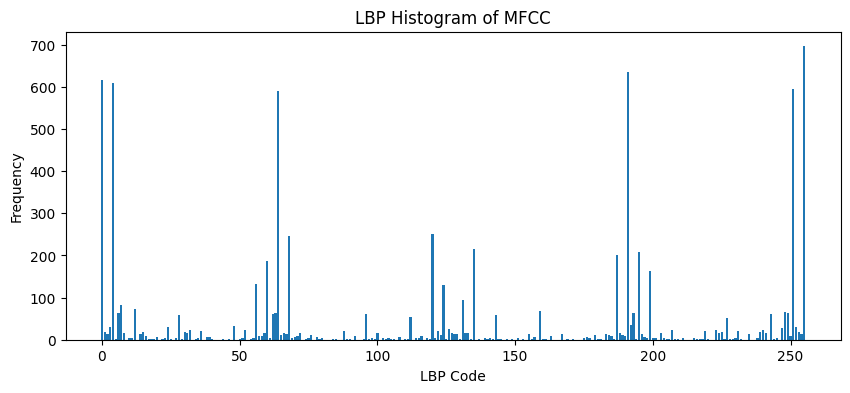

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\1.wav -> 118 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\10.wav
(201, 39)


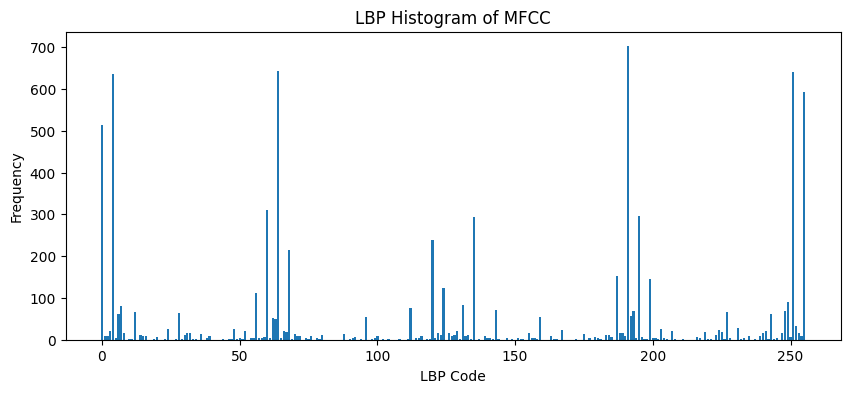

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\10.wav -> 15 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\100.wav
(201, 39)


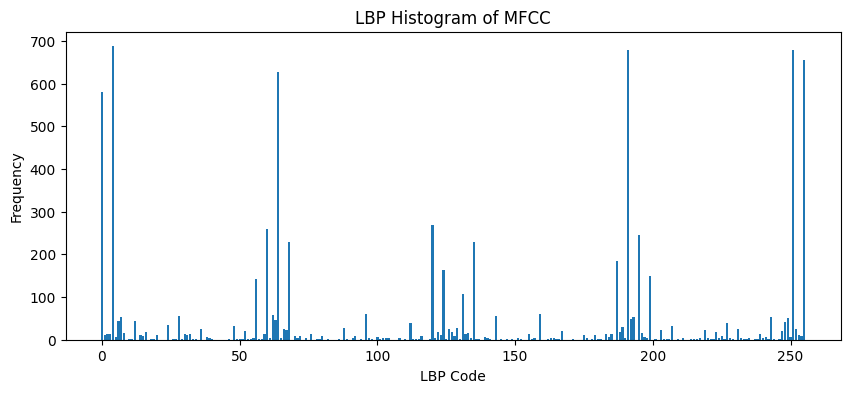

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\100.wav -> 98 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\101.wav
(201, 39)


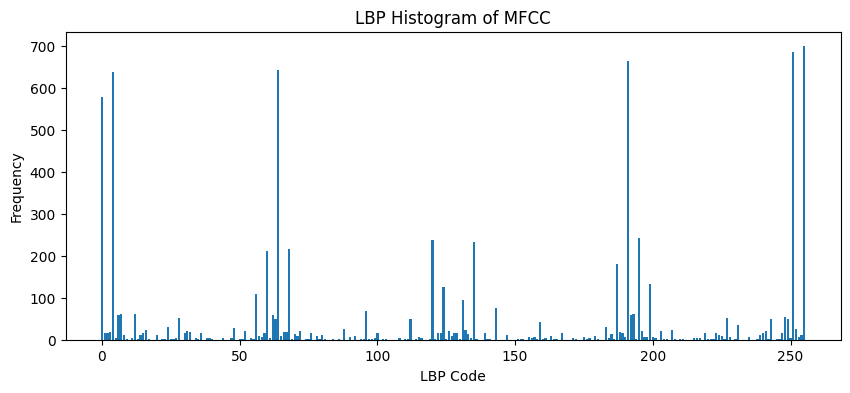

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\101.wav -> 83 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\102.wav
(201, 39)


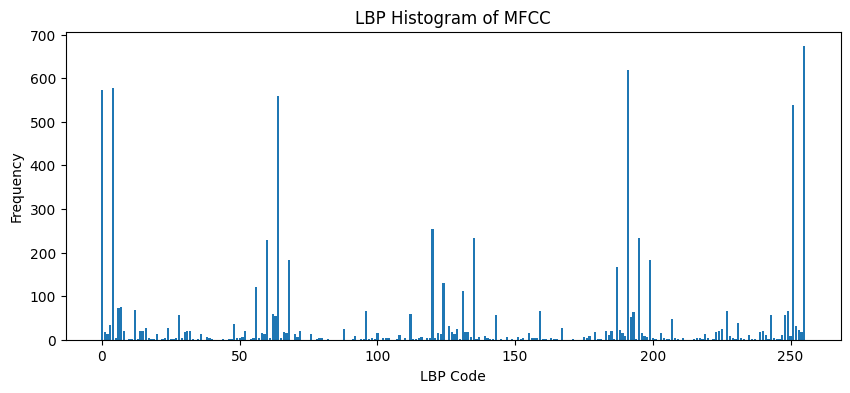

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\102.wav -> 33 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\103.wav
(201, 39)


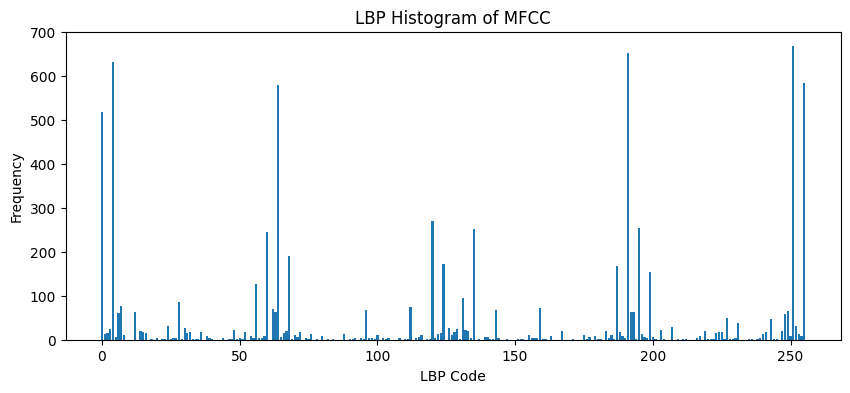

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\103.wav -> 136 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\104.wav
(201, 39)


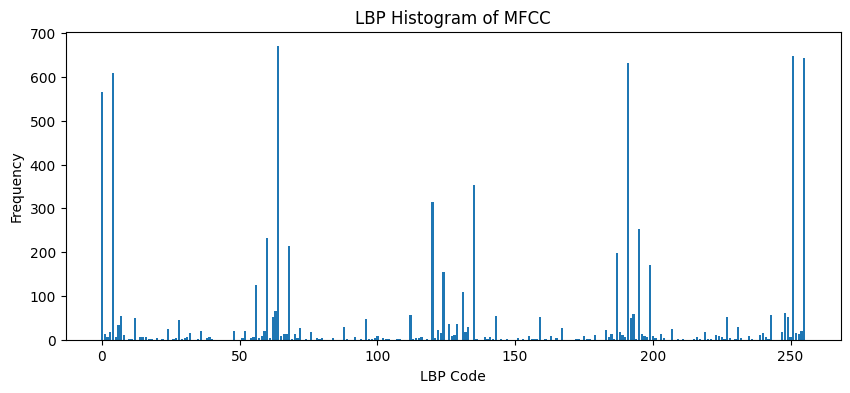

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\104.wav -> 73 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\105.wav
(201, 39)


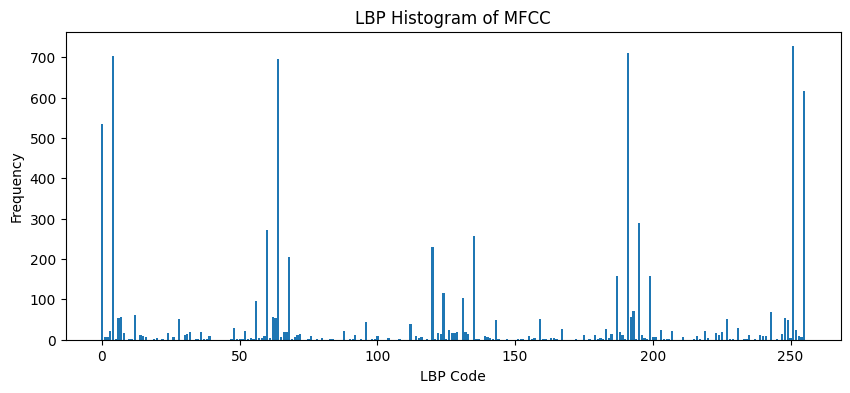

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\105.wav -> 48 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\106.wav
(201, 39)


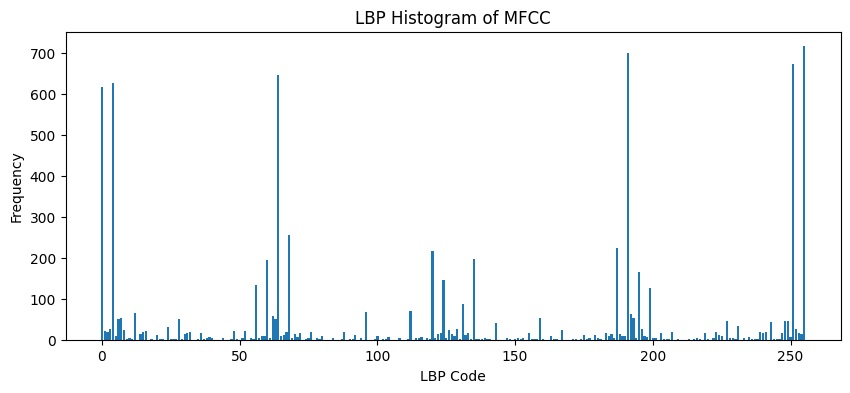

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\106.wav -> 67 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\107.wav
(201, 39)


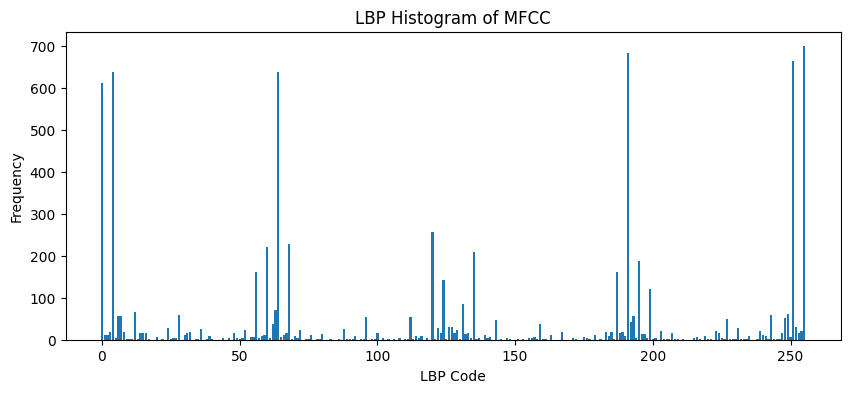

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\107.wav -> 49 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\108.wav
(201, 39)


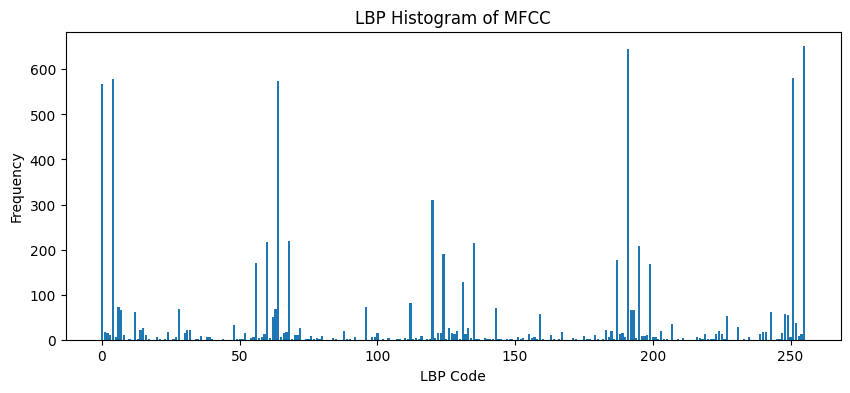

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\108.wav -> 130 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\109.wav
(201, 39)


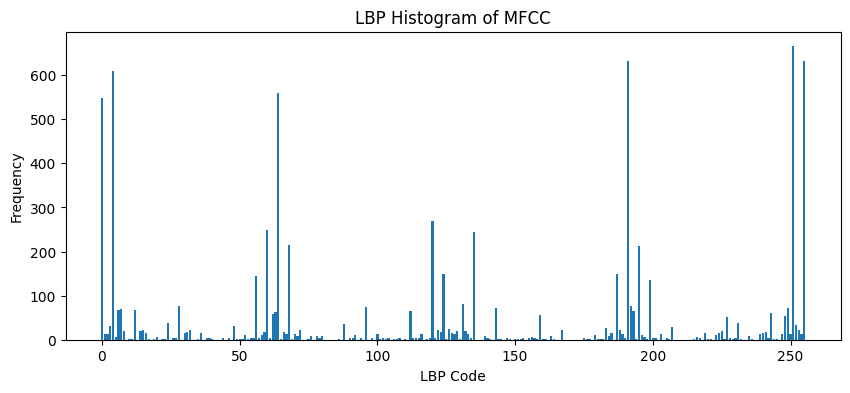

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\109.wav -> 115 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\11.wav
(201, 39)


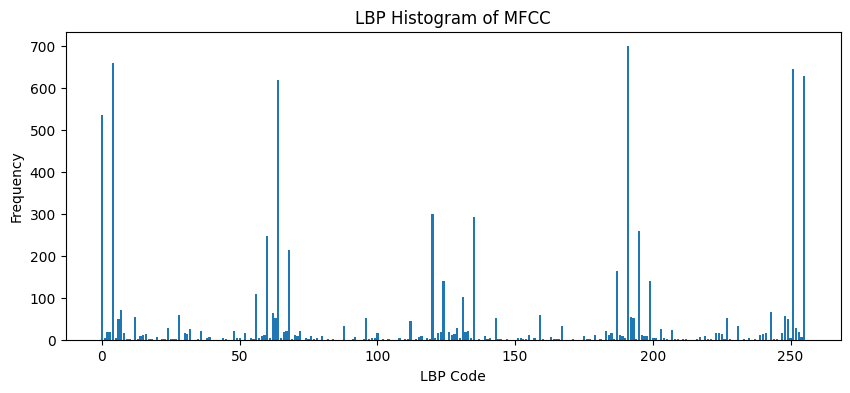

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\11.wav -> 191 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\110.wav
(201, 39)


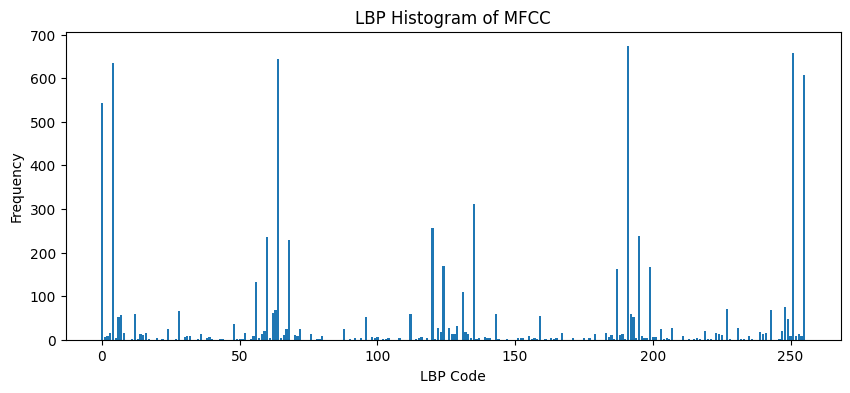

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\110.wav -> 53 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\111.wav
(201, 39)


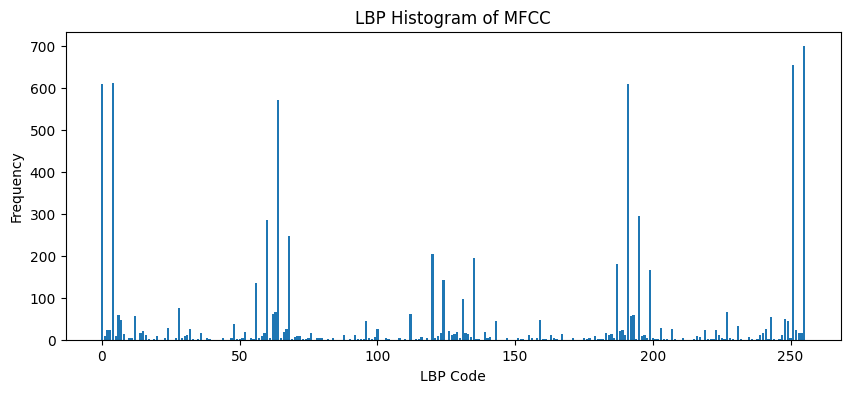

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\111.wav -> 13 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\112.wav
(201, 39)


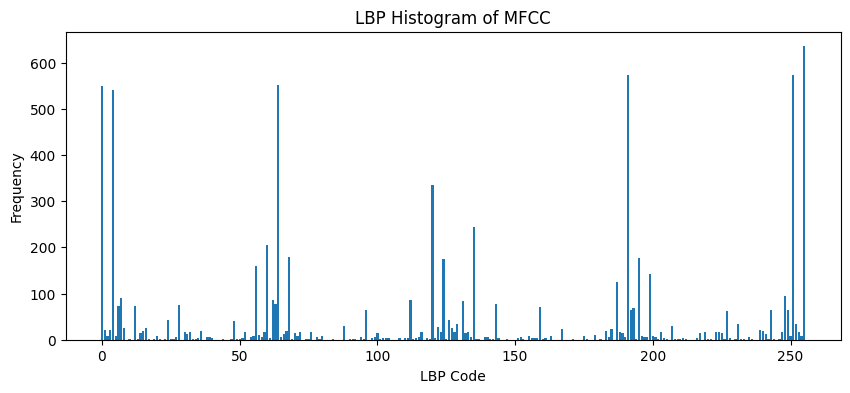

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\112.wav -> 67 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\113.wav
(201, 39)


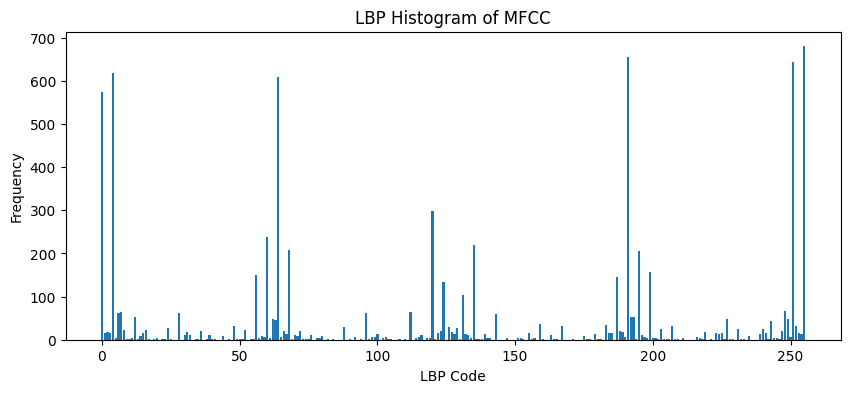

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\113.wav -> 189 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\114.wav
(201, 39)


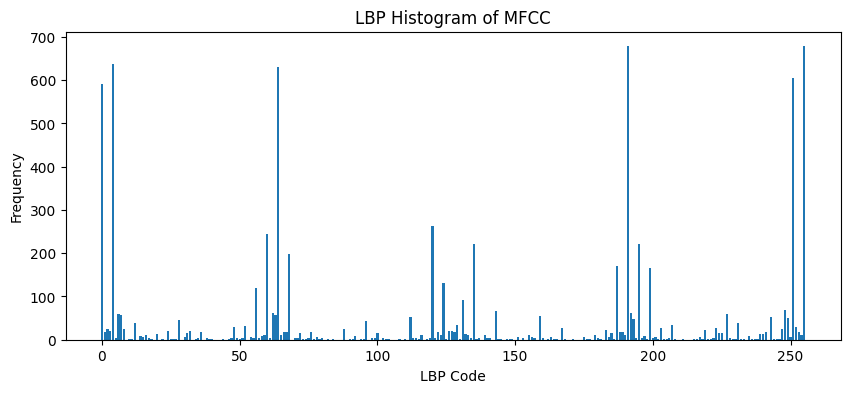

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\114.wav -> 135 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\115.wav
(201, 39)


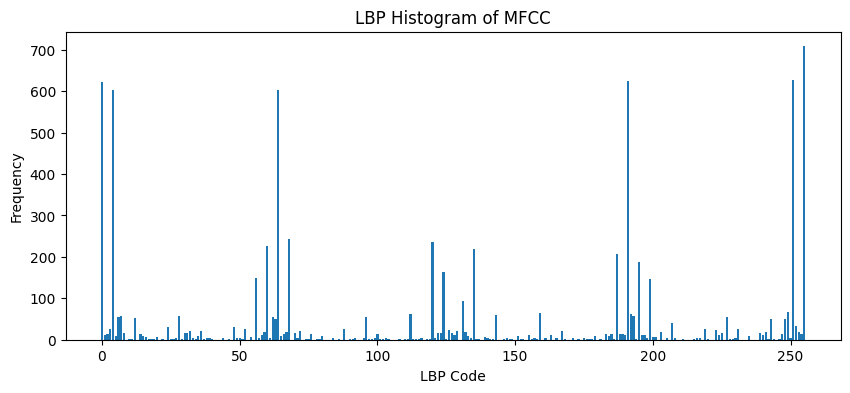

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\115.wav -> 32 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\116.wav
(201, 39)


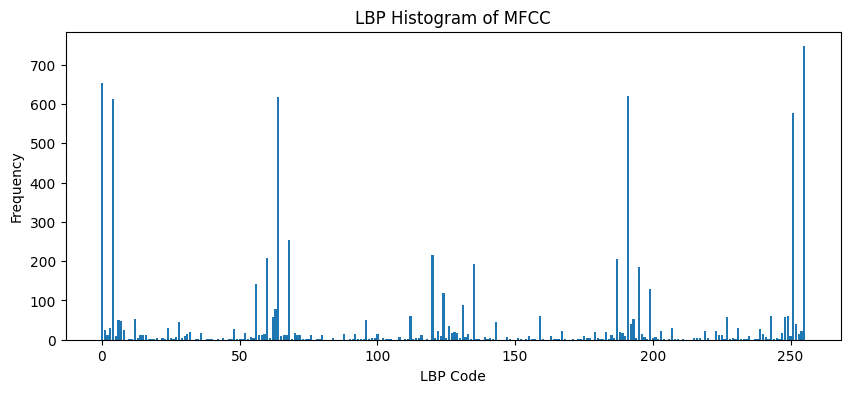

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\116.wav -> 56 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\117.wav
(201, 39)


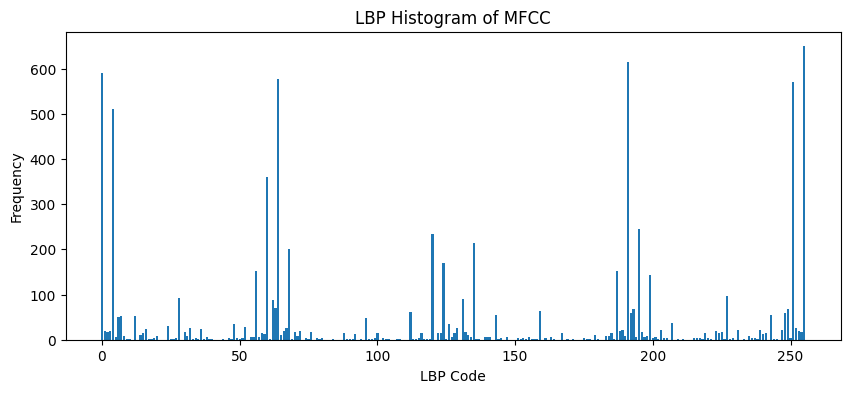

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\117.wav -> 262 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\118.wav
(201, 39)


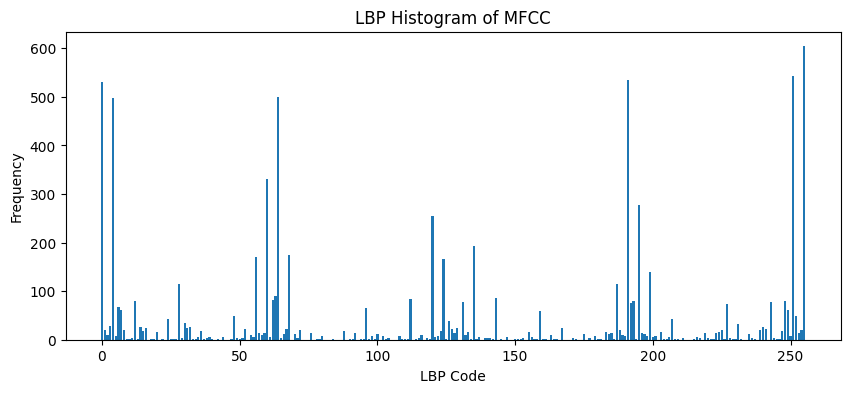

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\118.wav -> 112 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\119.wav
(201, 39)


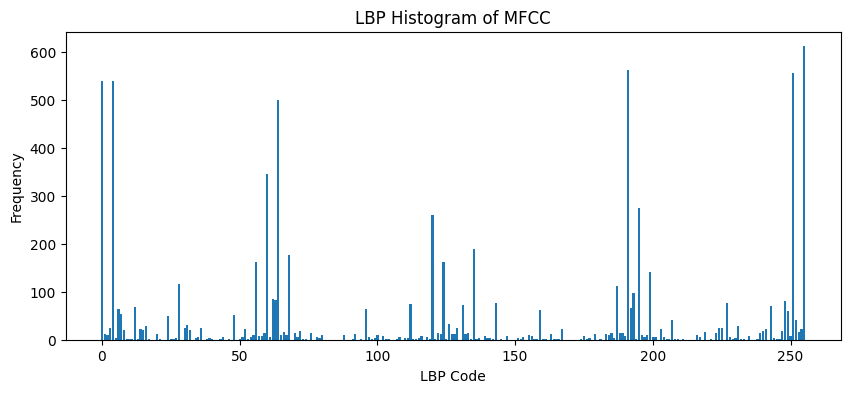

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\119.wav -> 112 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\12.wav
(201, 39)


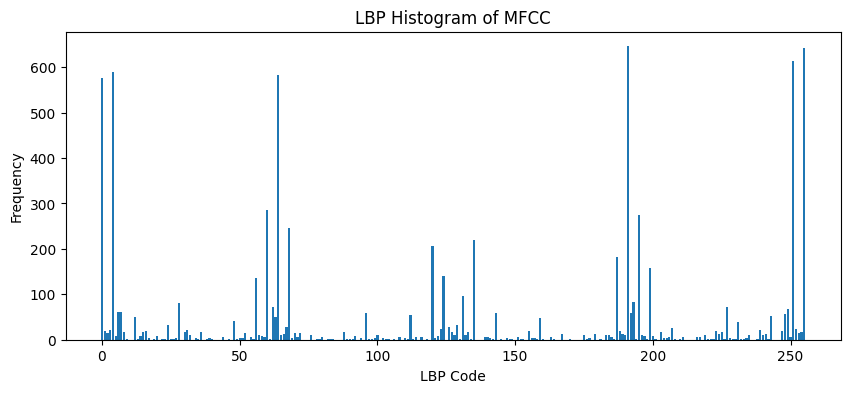

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\12.wav -> 95 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\120.wav
(201, 39)


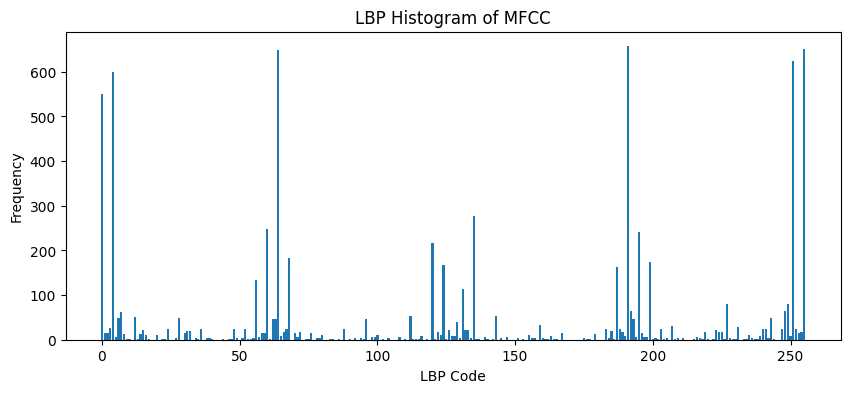

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\120.wav -> 205 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\121.wav
(201, 39)


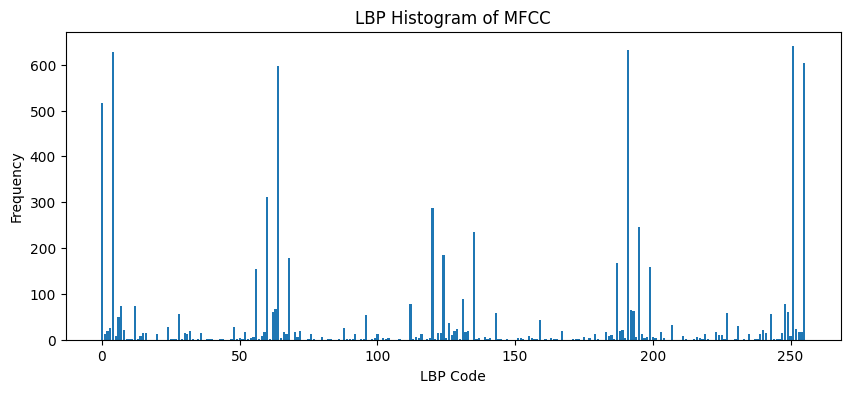

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\121.wav -> 200 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\122.wav
(201, 39)


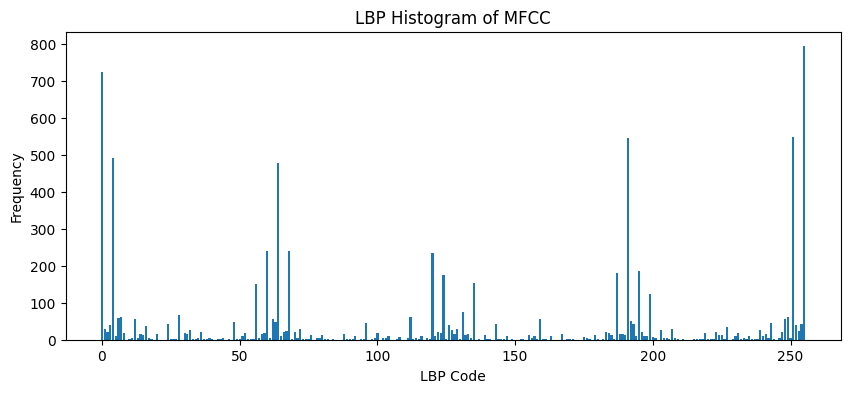

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\122.wav -> 252 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\123.wav
(201, 39)


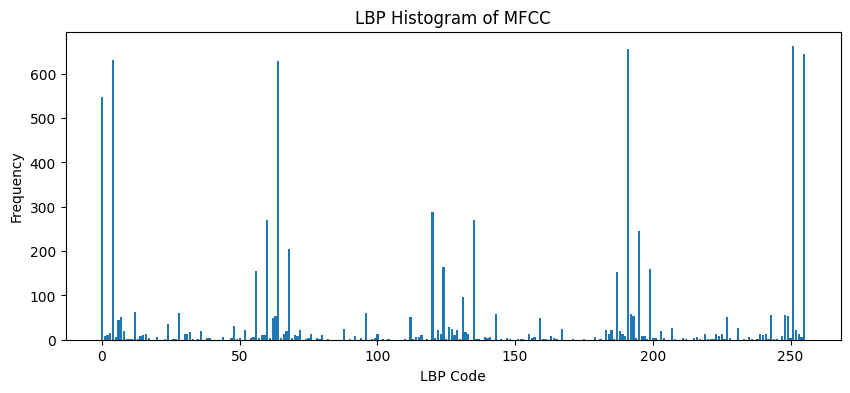

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\123.wav -> 289 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\124.wav
(201, 39)


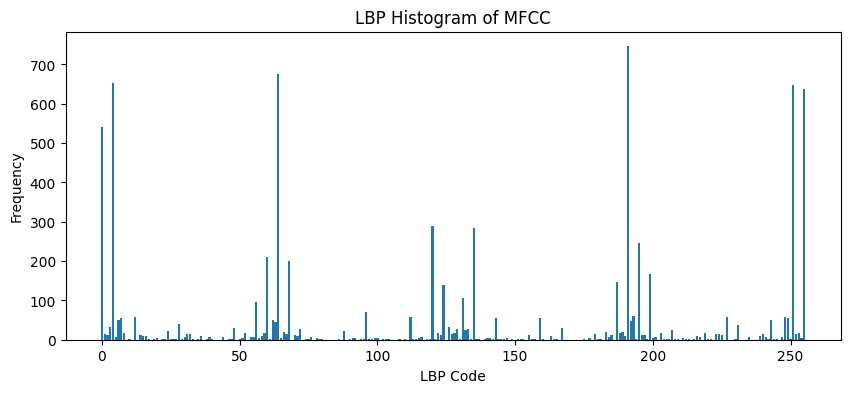

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\124.wav -> 45 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\125.wav
(201, 39)


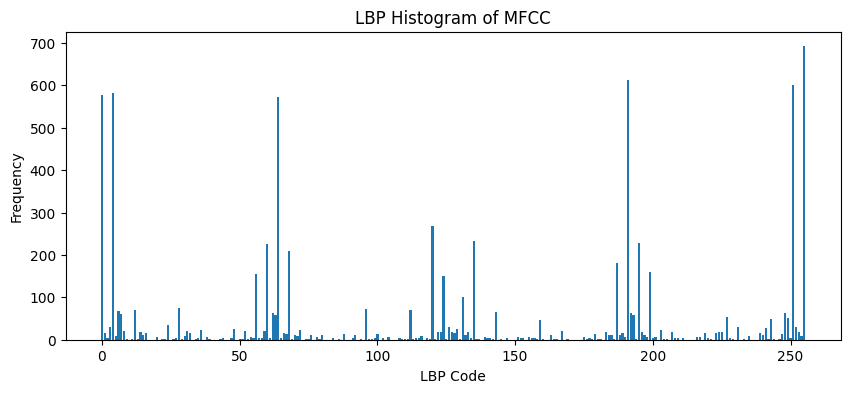

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\125.wav -> 45 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\126.wav
(201, 39)


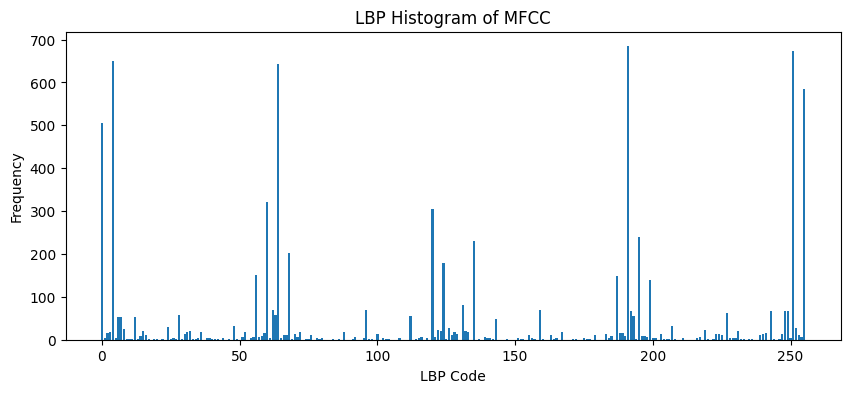

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\126.wav -> 63 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\127.wav
(201, 39)


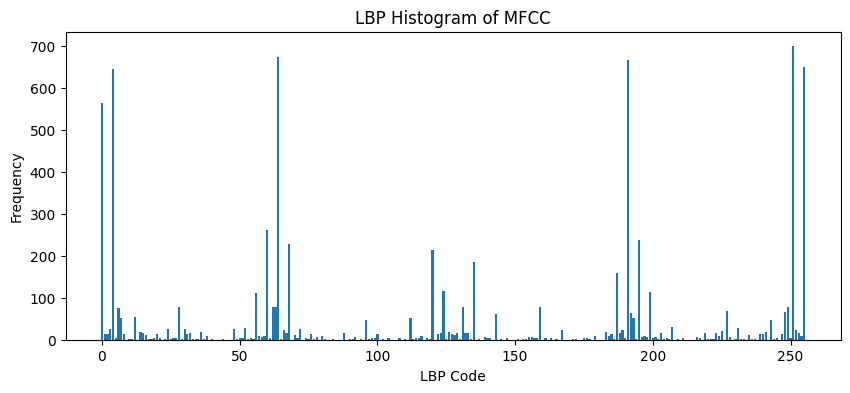

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\127.wav -> 52 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\128.wav
(201, 39)


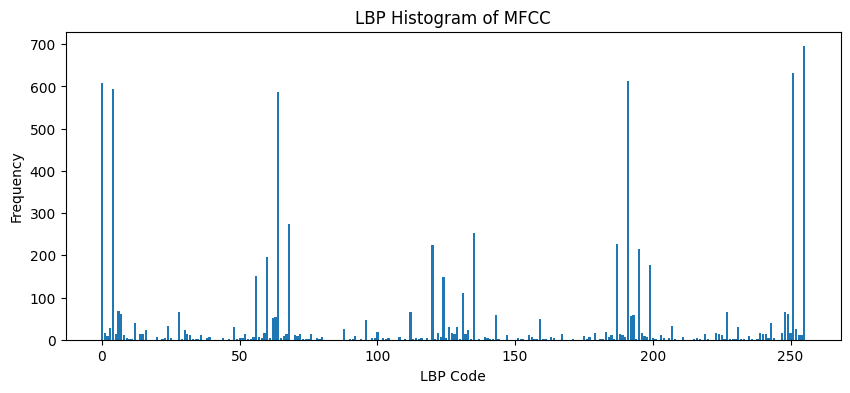

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\128.wav -> 112 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\129.wav
(201, 39)


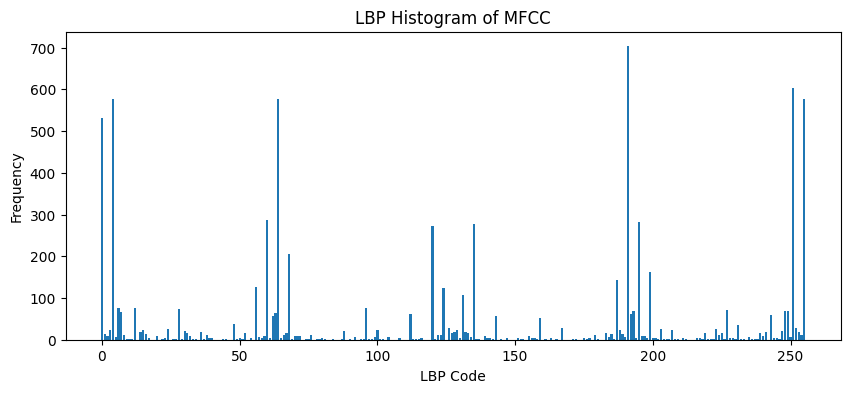

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\129.wav -> 17 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\13.wav
(201, 39)


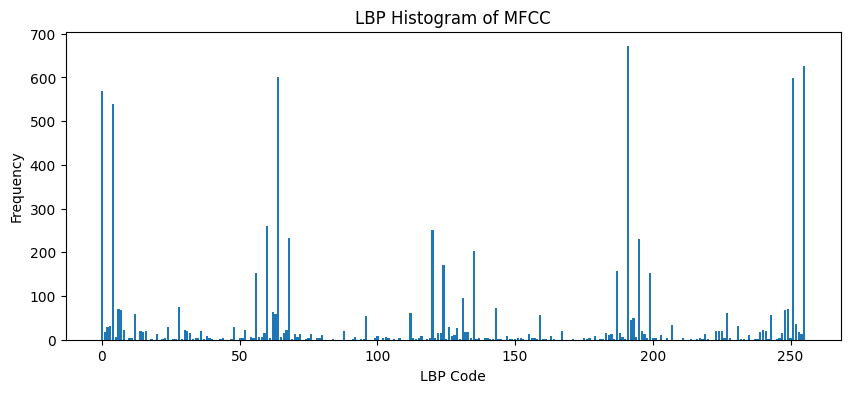

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\13.wav -> 228 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\130.wav
(201, 39)


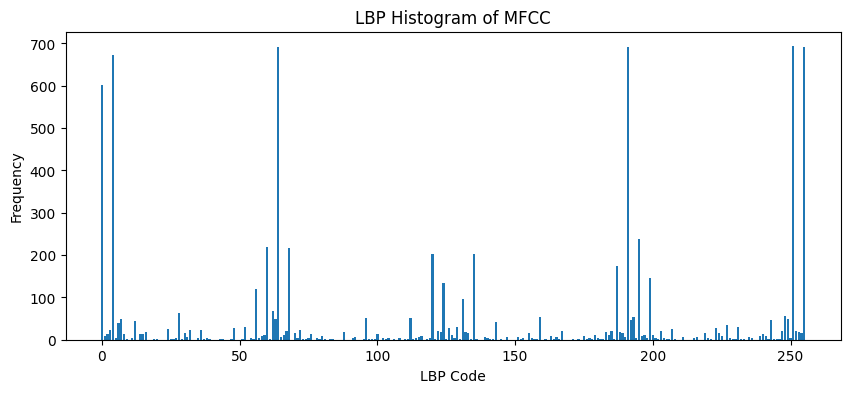

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\130.wav -> 18 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\131.wav
(201, 39)


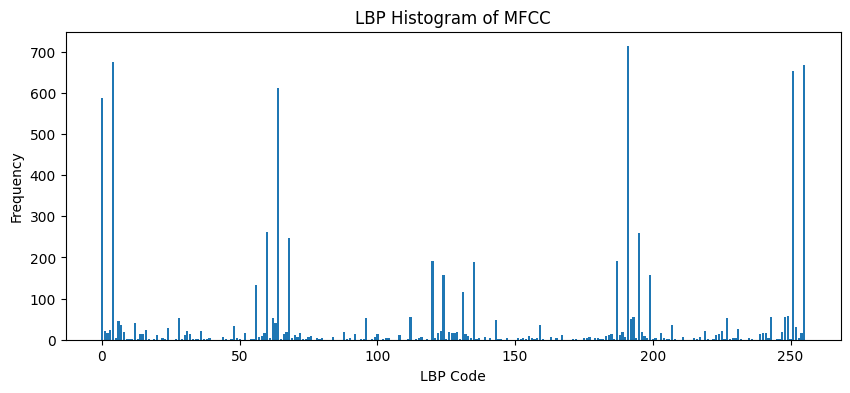

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\131.wav -> 27 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\132.wav
(201, 39)


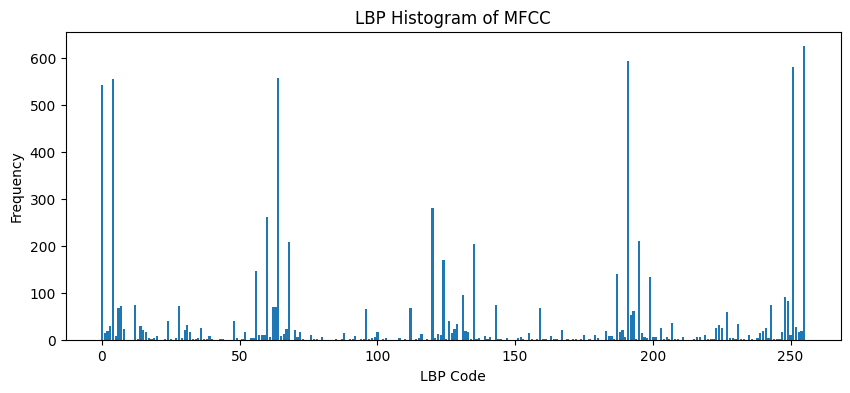

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\132.wav -> 116 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\133.wav
(201, 39)


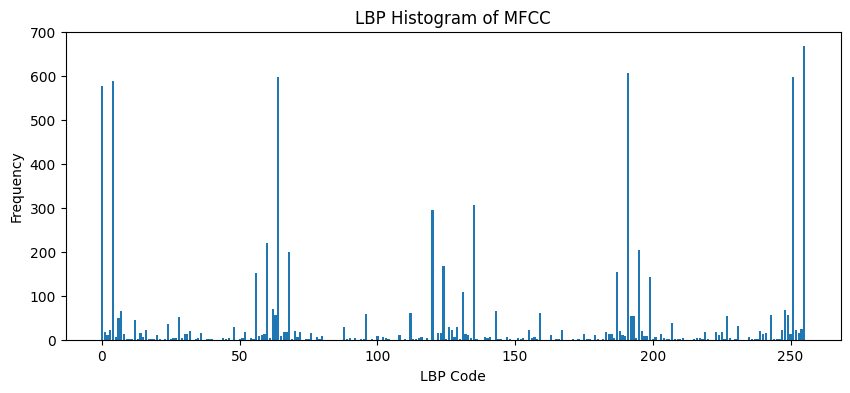

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\133.wav -> 12 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\134.wav
(201, 39)


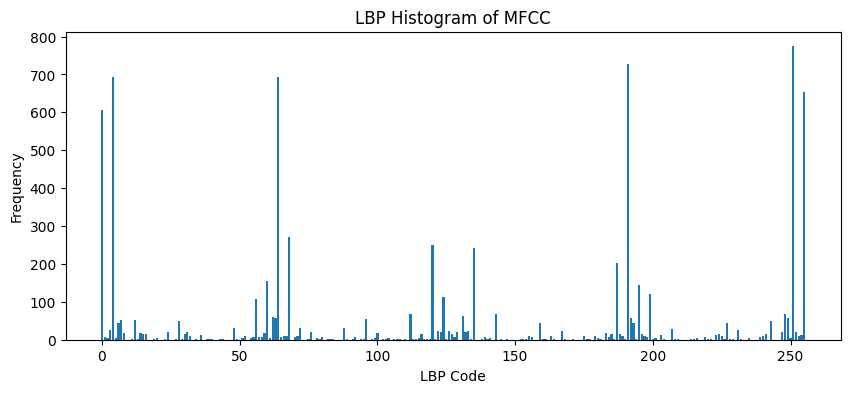

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\134.wav -> 166 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\135.wav
(201, 39)


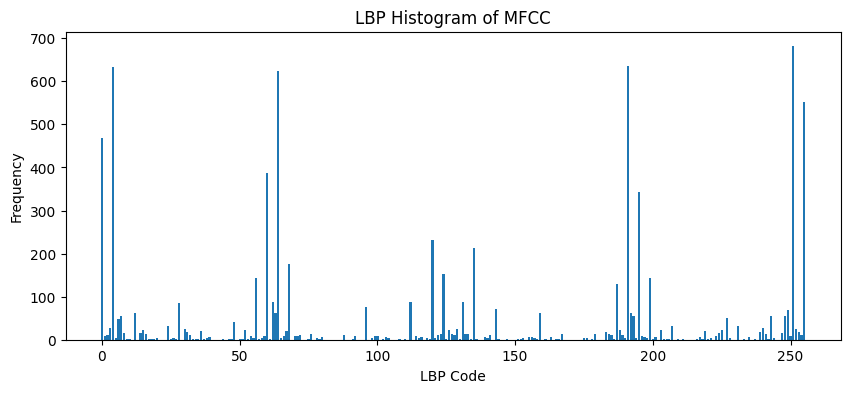

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\135.wav -> 190 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\136.wav
(201, 39)


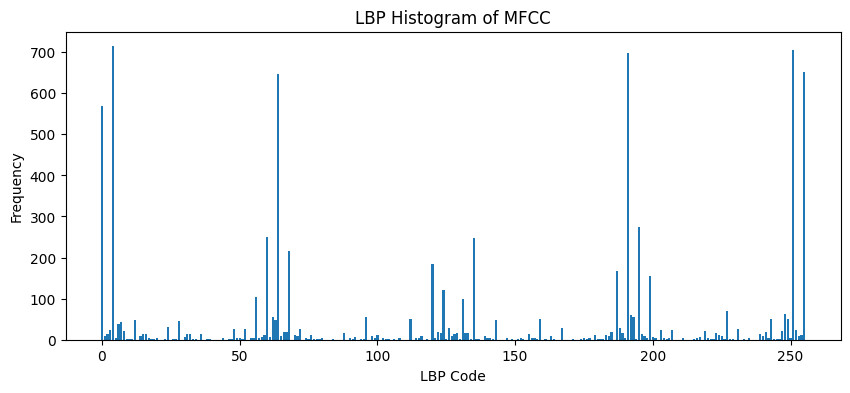

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\136.wav -> 48 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\137.wav
(201, 39)


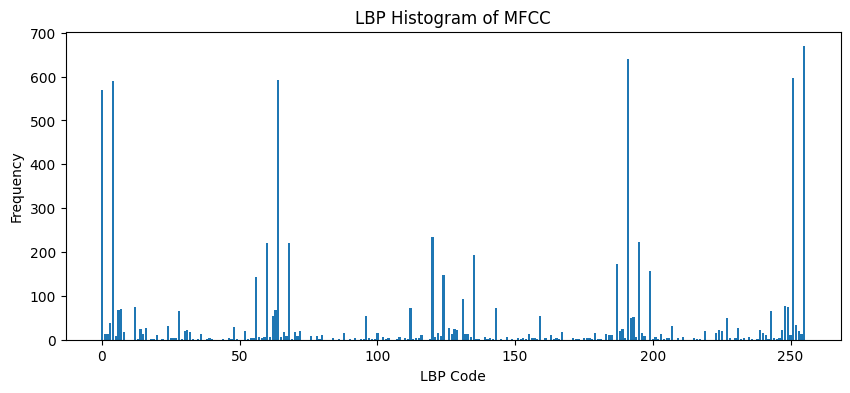

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\137.wav -> 147 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\138.wav
(201, 39)


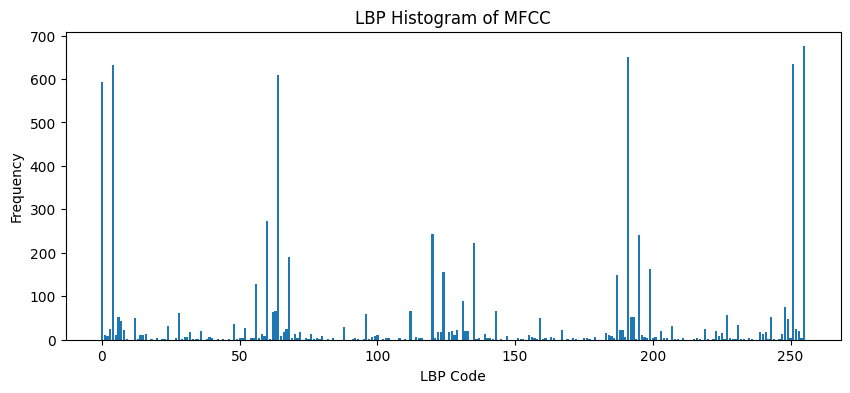

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\138.wav -> 172 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\139.wav
(201, 39)


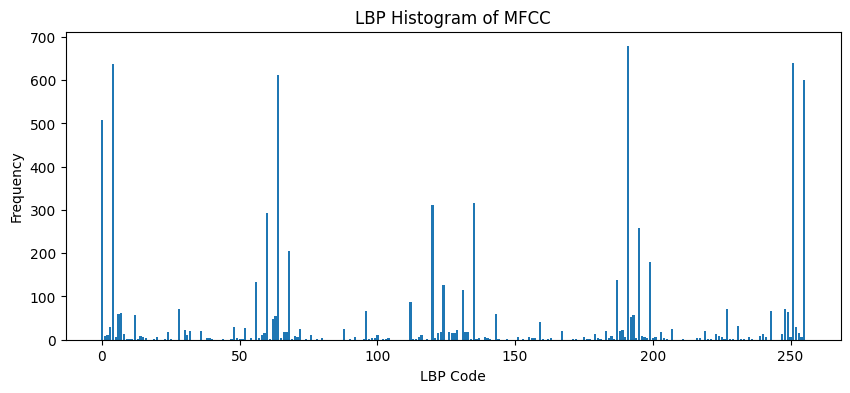

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\139.wav -> 40 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\14.wav
(201, 39)


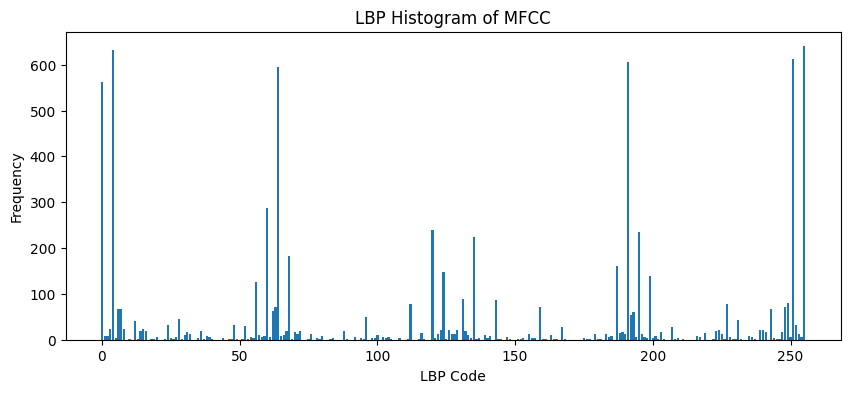

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\14.wav -> 276 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\140.wav
(201, 39)


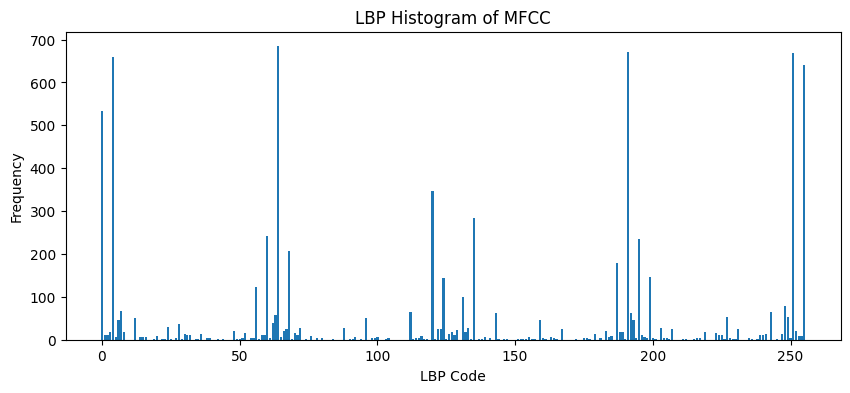

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\140.wav -> 28 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\141.wav
(201, 39)


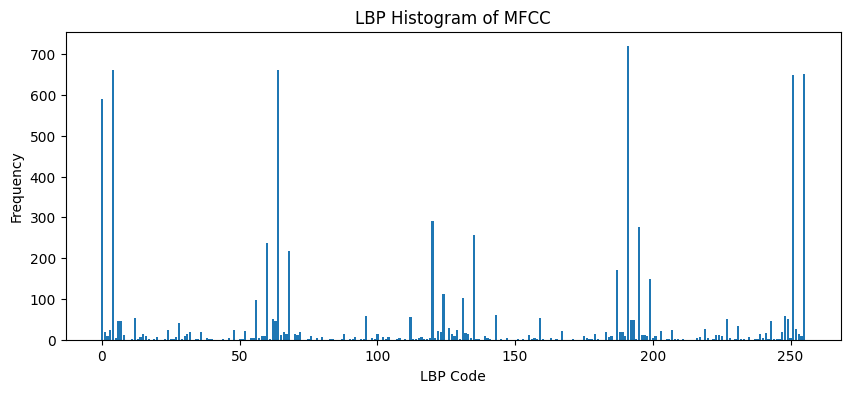

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\141.wav -> 75 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\142.wav
(201, 39)


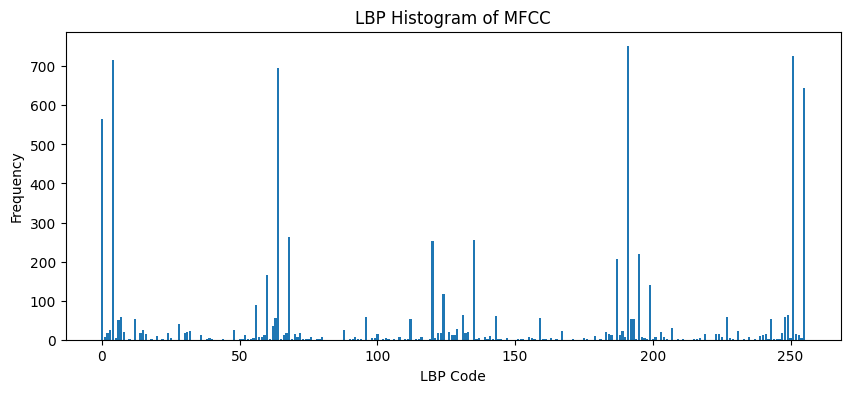

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\142.wav -> 22 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\143.wav
(201, 39)


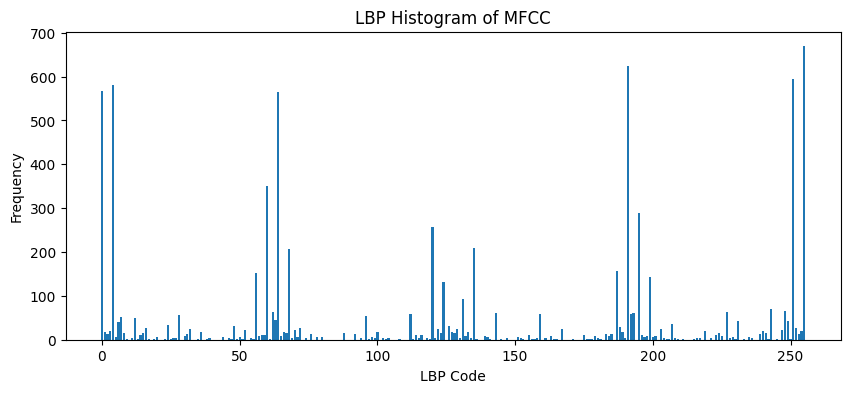

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\143.wav -> 121 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\144.wav
(201, 39)


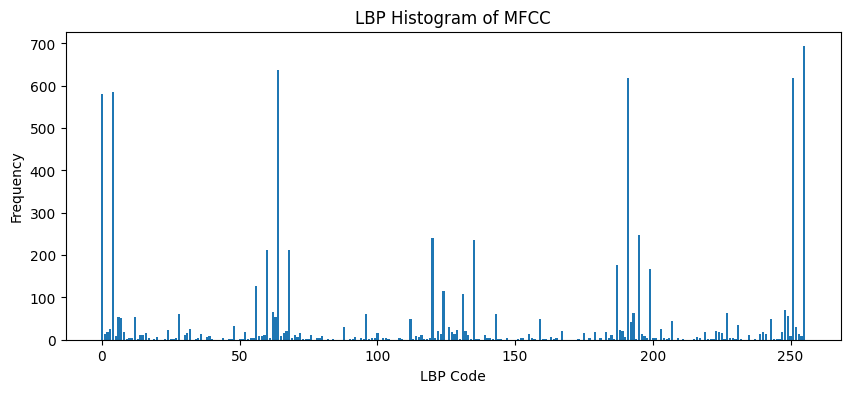

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\144.wav -> 154 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\145.wav
(201, 39)


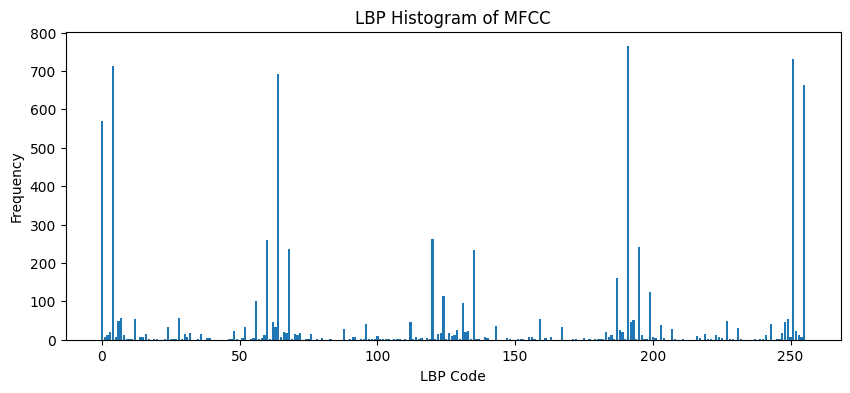

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\145.wav -> 30 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\146.wav
(201, 39)


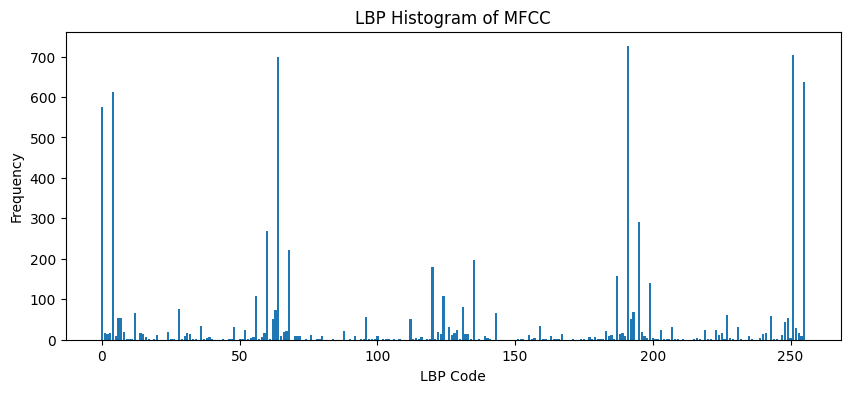

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\146.wav -> 142 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\147.wav
(201, 39)


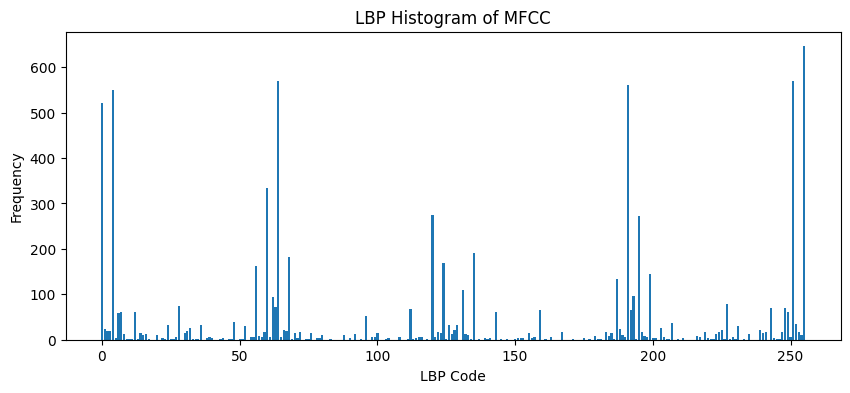

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\147.wav -> 29 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\148.wav
(201, 39)


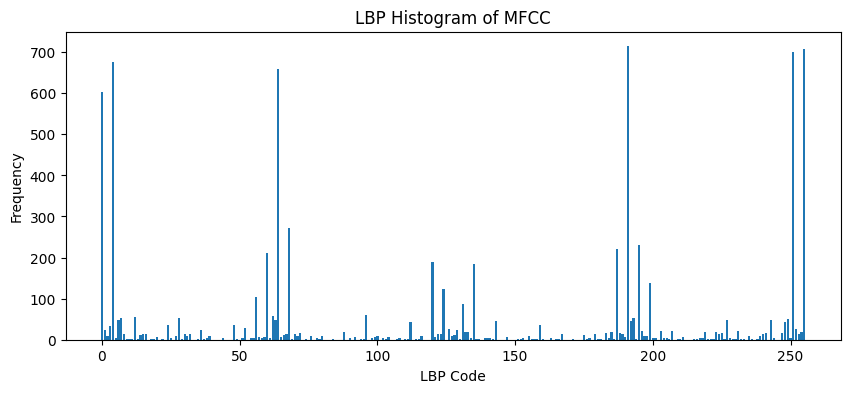

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\148.wav -> 67 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\149.wav
(201, 39)


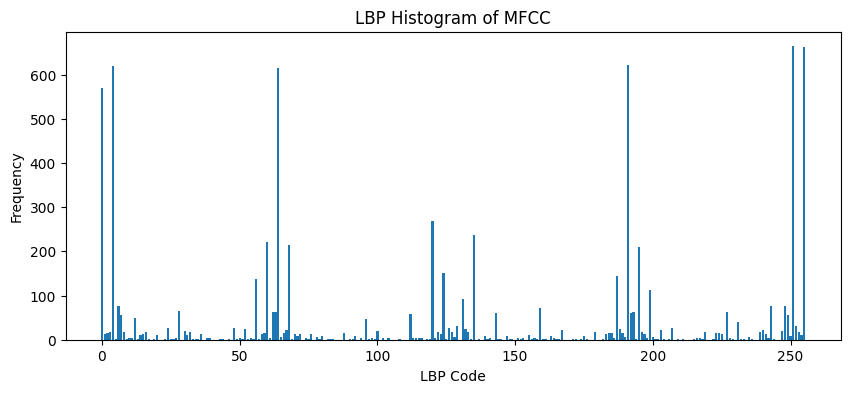

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\149.wav -> 161 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\15.wav
(201, 39)


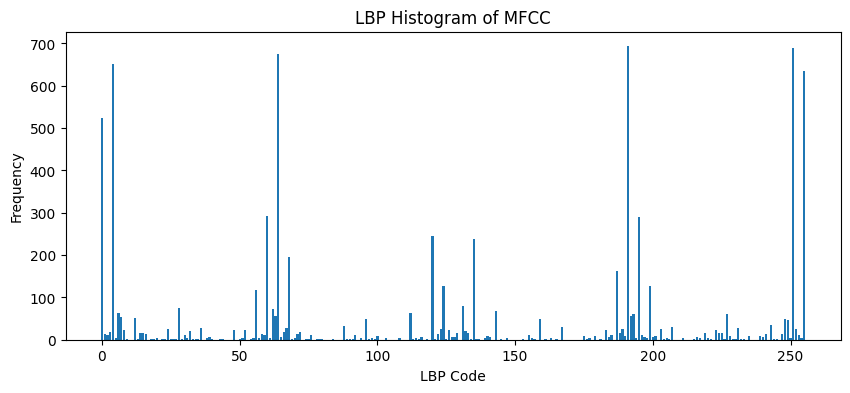

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\15.wav -> 236 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\150.wav
(201, 39)


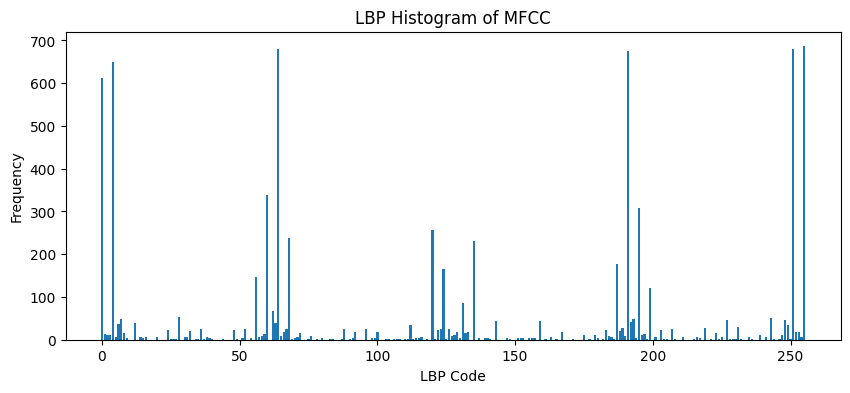

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\150.wav -> 85 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\151.wav
(201, 39)


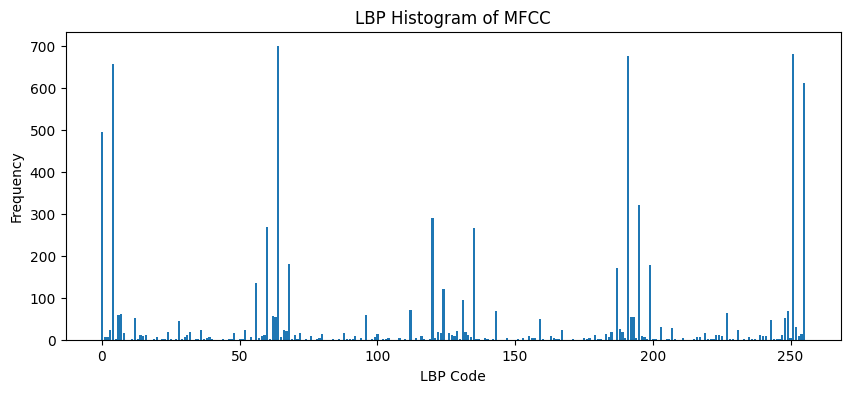

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\151.wav -> 177 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\152.wav
(201, 39)


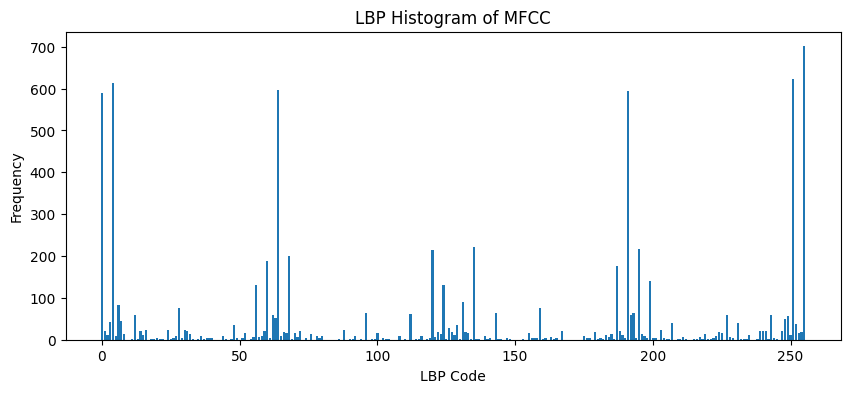

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\152.wav -> 137 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\153.wav
(201, 39)


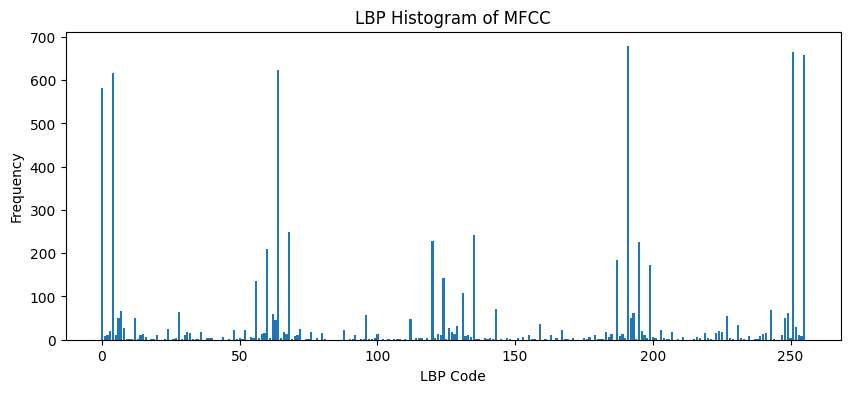

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\153.wav -> 84 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\154.wav
(201, 39)


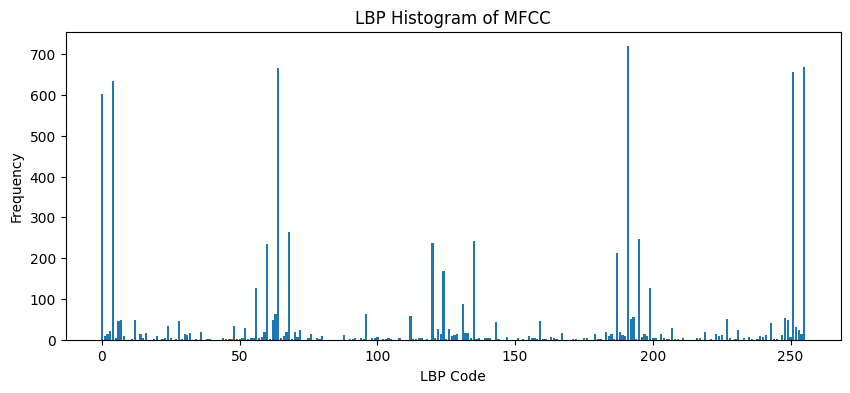

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\154.wav -> 203 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\155.wav
(201, 39)


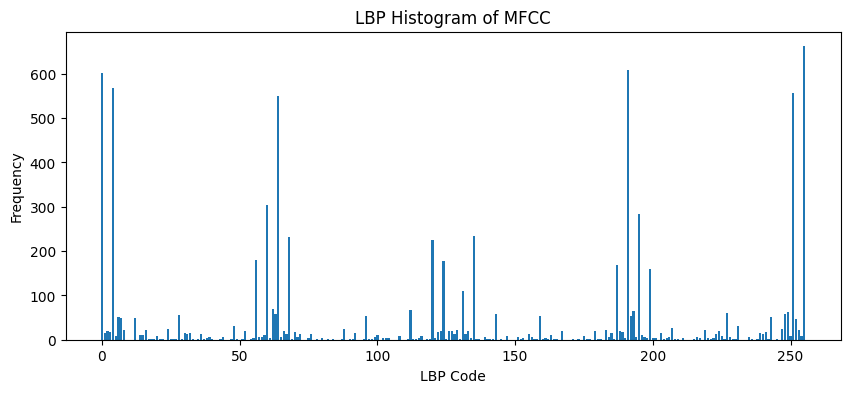

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\155.wav -> 172 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\156.wav
(201, 39)


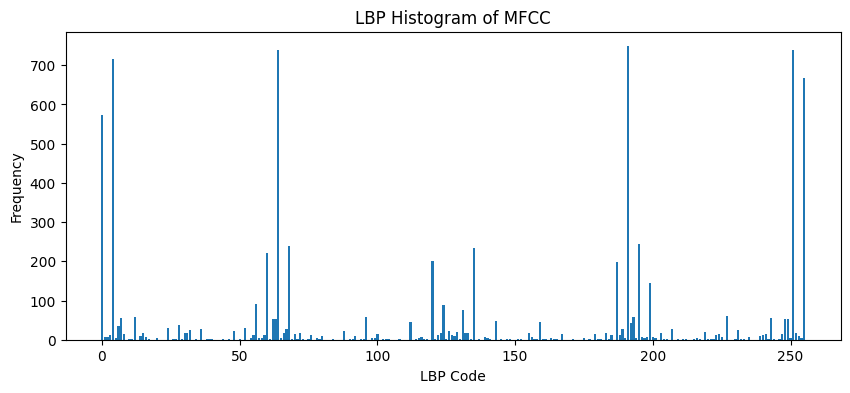

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\156.wav -> 196 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\157.wav
(201, 39)


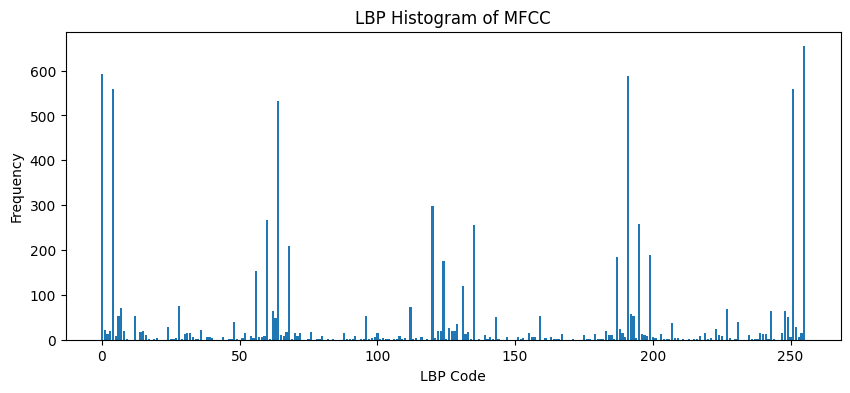

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\157.wav -> 173 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\158.wav
(201, 39)


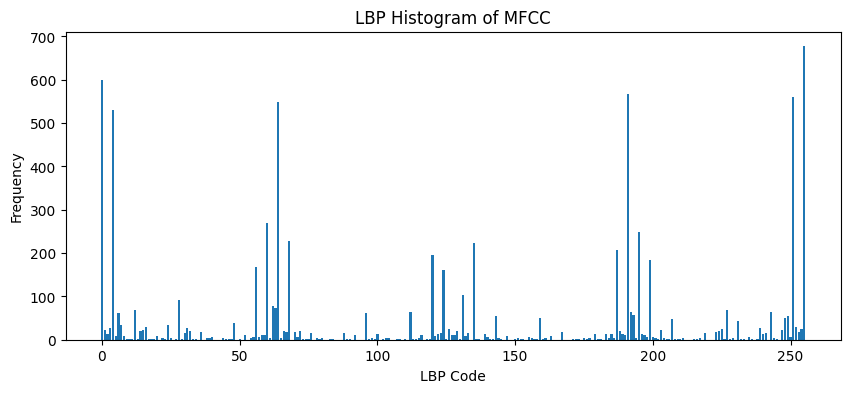

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\158.wav -> 172 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\159.wav
(201, 39)


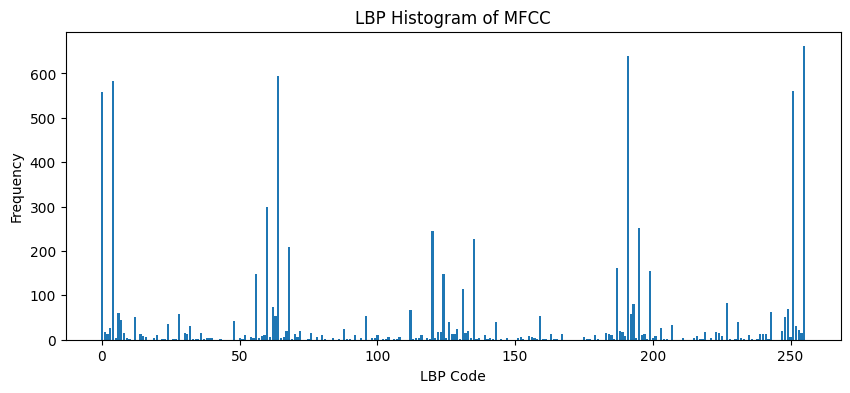

E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\159.wav -> 163 segments
Processing: E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed\16.wav
(201, 39)


KeyboardInterrupt: 

In [6]:
import os
CLASS = "bonafide"
SET = "eval"

DIR = f"E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed"

wav_list = [
    os.path.join(DIR, f)
    for f in os.listdir(DIR)
    if f.endswith(".wav")
]
print(wav_list)
X_mfcc = build_mfcc_dataset(
    wav_list,
    out_path=f"E:/PythonFile/Project/Voice-Activity-Detect/data/feature/train/mfcc_lbp_speech_aurora.npy"
)

print(len(wav_list))
print(X_mfcc.shape)